# Laboratorio 7 — Etapa 2: Simulación del Álbum FIFA 2026 (Escenario Real)
## MM3014 Teoría de Probabilidades · Universidad del Valle de Guatemala
## Diego Andre Calderon Salazar 241263 
## Pedro Julio Caso 241286 
---

### Introducción

Con la experiencia de la Etapa 1, ahora simulamos el álbum **real** del Mundial FIFA 2026 con $N = 980$ estampas distintas y $S = 7$ por sobre. Esta etapa aborda los cuatro objetivos del laboratorio:

| # | Objetivo |
|---|----------|
| 1 | Estimar el número esperado de sobres para completar la colección |
| 2 | Estimar el costo total esperado (individual vs. cajas) |
| 3 | Calcular la probabilidad de éxito con un presupuesto limitado |
| 4 | Cuantificar el efecto del intercambio de estampas repetidas |

**Precios:**
- Sobre individual: **Q 9.50**
- Caja de 104 sobres: **Q 975.00** (equivale a Q 9.375/sobre)

**Semilla obligatoria:** `2026`

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

## Parámetros del problema

In [11]:
N = 980 # total de estampas distintas para llenar el album
S = 7 # estampas por sobre
R = 10000
SEED = 2026

PRECIO_SOBRE = 9.5
PRECIO_CAJA = 975.00
SOBRES_POR_CAJA = 104
PRECIO_SOBRE_CAJA = PRECIO_CAJA / SOBRES_CAJA



---
## Objetivo 1: Número esperado de sobres

### Simulación base (sin intercambio)

In [6]:
np.random.seed(SEED)

sobres_result    = np.zeros(R, dtype=int)
repetidas_result = np.zeros(R, dtype=int)

for i in range(R):
    album     = np.zeros(N, dtype=bool)
    sobres    = 0
    repetidas = 0
    count     = 0

    while count < N:
        stickers   = np.random.choice(N, size=S, replace=False)
        nuevas     = ~album[stickers]
        n_nuevas   = int(nuevas.sum())
        repetidas += S - n_nuevas
        count     += n_nuevas
        album[stickers] = True
        sobres += 1

    sobres_result[i]    = sobres
    repetidas_result[i] = repetidas

print(f"Simulación completa: {R:,} repeticiones.")

Simulación completa: 10,000 repeticiones.


In [8]:
# Estadísticas empíricas
media_sobres = np.mean(sobres_result)
std_sobres   = np.std(sobres_result)
media_rep    = np.mean(repetidas_result)
std_rep      = np.std(repetidas_result)
min_teorico  = math.ceil(N / S)

# Teoría del coleccionista
GAMMA       = 0.5772156649015329
H_N         = sum(1/k for k in range(1, N + 1))
E_T_teorico = (N / S) * H_N
E_rep_teo   = N * (H_N - 1)



print(f"  RESULTADOS ETAPA 2  (N={N}, S={S}, R={R:,})")
print(f"\n  Sobres necesarios:")
print(f"    Media simulada     : {media_sobres:.2f}")
print(f"    Desv. estándar     : {std_sobres:.2f}")
print(f"    Valor teórico E[T] : {E_T_teorico:.2f}")
print(f"    Error relativo     : {abs(E_T_teorico-media_sobres)/E_T_teorico*100:.3f}%")
print(f"\n  Estampas repetidas:")
print(f"    Media simulada     : {media_rep:.2f}")
print(f"    Valor teórico      : {E_rep_teo:.2f}")
print(f"\n  Mínimo teórico (sin repetidas): {min_teorico} sobres  (⌈{N}/{S}⌉)")


  RESULTADOS ETAPA 2  (N=980, S=7, R=10,000)

  Sobres necesarios:
    Media simulada     : 1042.70
    Desv. estándar     : 177.82
    Valor teórico E[T] : 1045.14
    Error relativo     : 0.234%

  Estampas repetidas:
    Media simulada     : 6318.87
    Valor teórico      : 6335.97

  Mínimo teórico (sin repetidas): 140 sobres  (⌈980/7⌉)


### Visualización 1 — Distribución de sobres necesarios

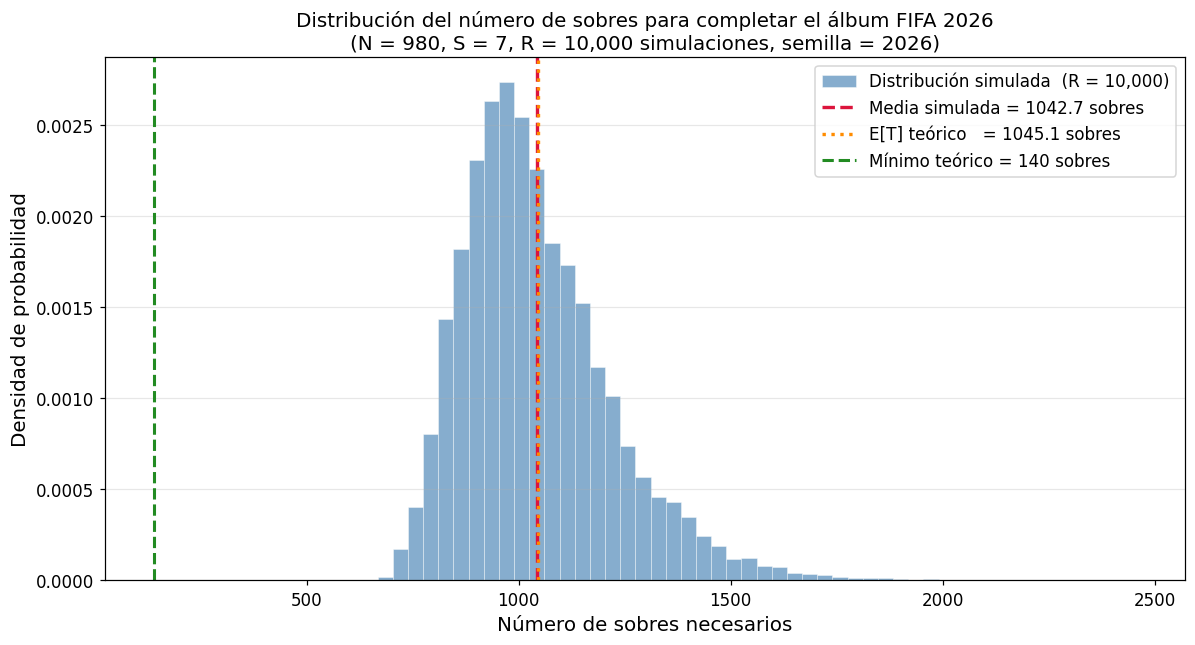

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(sobres_result, bins=50, density=True, alpha=0.65,
        color='steelblue', edgecolor='white', linewidth=0.4,
        label=f'Distribución simulada  (R = {R:,})')

ax.axvline(media_sobres, color='crimson', linestyle='--', linewidth=2.2,
           label=f'Media simulada = {media_sobres:.1f} sobres')
ax.axvline(E_T_teorico, color='darkorange', linestyle=':', linewidth=2.2,
           label=f'E[T] teórico   = {E_T_teorico:.1f} sobres')
ax.axvline(min_teorico, color='forestgreen', linestyle='--', linewidth=2.0,
           label=f'Mínimo teórico = {min_teorico} sobres')

ax.set_xlabel('Número de sobres necesarios', fontsize=13)
ax.set_ylabel('Densidad de probabilidad', fontsize=13)
ax.set_title(
    f'Distribución del número de sobres para completar el álbum FIFA 2026\n'
    f'(N = {N}, S = {S}, R = {R:,} simulaciones, semilla = {SEED})',
    fontsize=13
)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## Objetivo 2: Análisis de costos

Se comparan dos estrategias de compra:
- **Individual:** comprar sobres uno a uno a Q 9.50.
- **Por cajas:** comprar cajas de 104 sobres a Q 975.00 (redondeando hacia arriba).
- **Mixta:** comprar cajas hasta cubrir la mayor parte, complementar con individuales.

In [12]:
def costo_individual(n_sobres):
    return n_sobres * PRECIO_SOBRE

def costo_por_cajas(n_sobres):
    """Comprar sólo cajas completas (puede sobrar presupuesto)."""
    n_cajas = math.ceil(n_sobres / SOBRES_POR_CAJA)
    return n_cajas * PRECIO_CAJA

def costo_mixto(n_sobres):
    """Cajas completas + individuales para los sobres restantes."""
    n_cajas      = n_sobres // SOBRES_POR_CAJA
    n_individuales = n_sobres % SOBRES_POR_CAJA
    return n_cajas * PRECIO_CAJA + n_individuales * PRECIO_SOBRE

costos_individual = np.array([costo_individual(s) for s in sobres_result])
costos_cajas      = np.array([costo_por_cajas(s) for s in sobres_result])
costos_mixto      = np.array([costo_mixto(s) for s in sobres_result])

sep = "-" * 58
print(f"{'Estrategia':<22} {'Media (Q)':>12} {'Std (Q)':>10} {'Mín (Q)':>10} {'Máx (Q)':>10}")
print(sep)
for nombre, arr in [("Individual", costos_individual),
                    ("Por cajas", costos_cajas),
                    ("Mixta", costos_mixto)]:
    print(f"{nombre:<22} {np.mean(arr):>12.2f} {np.std(arr):>10.2f} "
          f"{np.min(arr):>10.2f} {np.max(arr):>10.2f}")
print(sep)
ahorro_cajas = np.mean(costos_individual) - np.mean(costos_cajas)
ahorro_mixto = np.mean(costos_individual) - np.mean(costos_mixto)
print(f"\nAhorro esperado (Individual - Por cajas) : Q {ahorro_cajas:>8.2f}")
print(f"Ahorro esperado (Individual - Mixta)     : Q {ahorro_mixto:>8.2f}")

Estrategia                Media (Q)    Std (Q)    Mín (Q)    Máx (Q)
----------------------------------------------------------
Individual                  9905.61    1689.28    6336.50   23322.50
Por cajas                  10255.54    1690.73    6825.00   23400.00
Mixta                       9781.74    1667.07    6258.50   23023.50
----------------------------------------------------------

Ahorro esperado (Individual - Por cajas) : Q  -349.93
Ahorro esperado (Individual - Mixta)     : Q   123.87


### Visualización 2 — Distribución de costos por estrategia

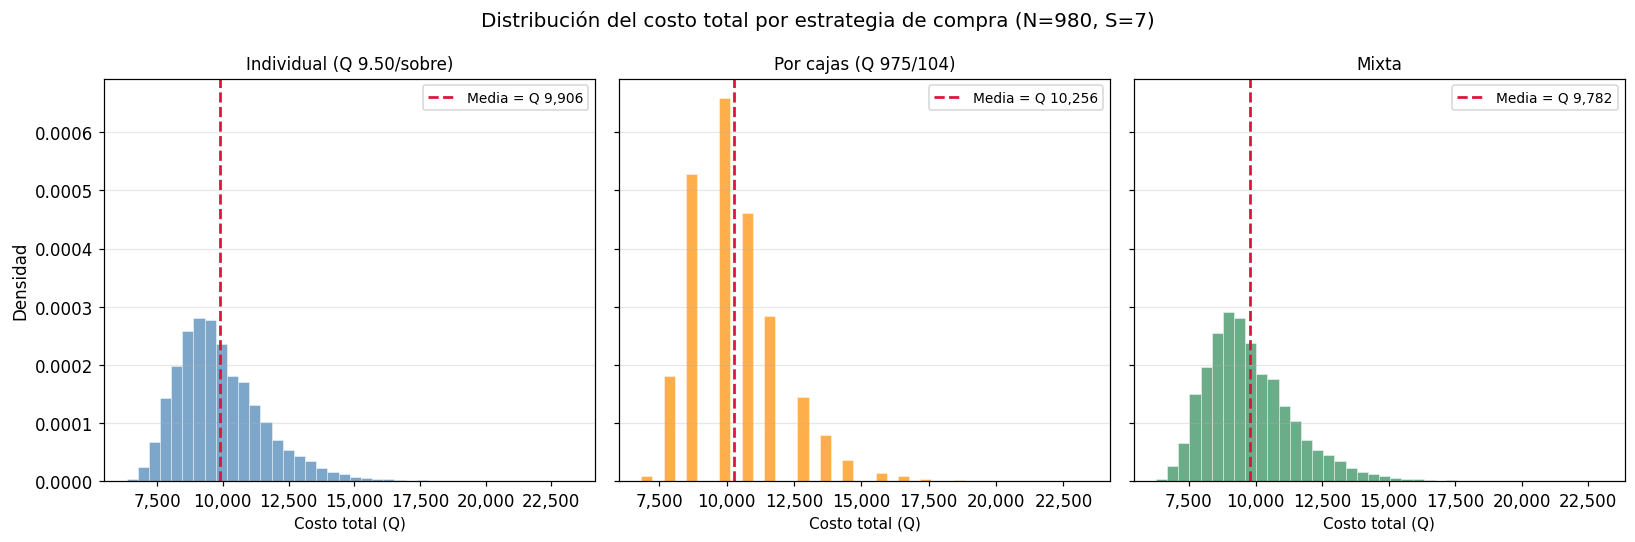

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

datos_plot = [
    (costos_individual, 'Individual (Q 9.50/sobre)', 'steelblue'),
    (costos_cajas,      'Por cajas (Q 975/104)',      'darkorange'),
    (costos_mixto,      'Mixta',                      'seagreen'),
]

for ax, (arr, titulo, color) in zip(axes, datos_plot):
    ax.hist(arr, bins=40, density=True, alpha=0.7, color=color,
            edgecolor='white', linewidth=0.4)
    ax.axvline(np.mean(arr), color='crimson', linestyle='--', linewidth=1.8,
               label=f'Media = Q {np.mean(arr):,.0f}')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Costo total (Q)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[0].set_ylabel('Densidad', fontsize=11)
fig.suptitle('Distribución del costo total por estrategia de compra (N=980, S=7)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Objetivo 3: Probabilidad de éxito con presupuesto limitado

¿Con qué probabilidad se puede completar el álbum dado un presupuesto fijo?

Para cada presupuesto $B$, el máximo de sobres comprables es:
- **Individual:** $\lfloor B / 9.50 \rfloor$ sobres
- **Por cajas:** $\lfloor B / 975 \rfloor \times 104$ sobres

In [14]:
presupuestos = np.arange(2000, 20001, 500)  # Q 2,000 a Q 20,000 en pasos de Q 500

prob_individual = np.array([
    np.mean(sobres_result <= math.floor(B / PRECIO_SOBRE))
    for B in presupuestos
])

prob_cajas = np.array([
    np.mean(sobres_result <= (math.floor(B / PRECIO_CAJA) * SOBRES_POR_CAJA))
    for B in presupuestos
])

# Presupuestos para probabilidades clave
from scipy.interpolate import interp1d

interp_ind  = interp1d(prob_individual, presupuestos, bounds_error=False, fill_value='extrapolate')
interp_caja = interp1d(prob_cajas,      presupuestos, bounds_error=False, fill_value='extrapolate')

print(f"{'Probabilidad':>15} {'Presupuesto (Individual)':>25} {'Presupuesto (Por cajas)':>25}")
print("-" * 68)
for p in [0.50, 0.75, 0.90, 0.95, 0.99]:
    b_ind  = float(interp_ind(p))
    b_caja = float(interp_caja(p))
    print(f"{p*100:>14.0f}%  Q {b_ind:>22,.0f}    Q {b_caja:>22,.0f}")

   Probabilidad  Presupuesto (Individual)   Presupuesto (Por cajas)
--------------------------------------------------------------------
            50%  Q                  9,615    Q                  9,870
            75%  Q                 10,827    Q                 10,969
            90%  Q                 12,144    Q                 12,667
            95%  Q                 13,119    Q                 13,655
            99%  Q                 15,100    Q                 15,689


### Visualización 3 — Curva de probabilidad de éxito vs presupuesto

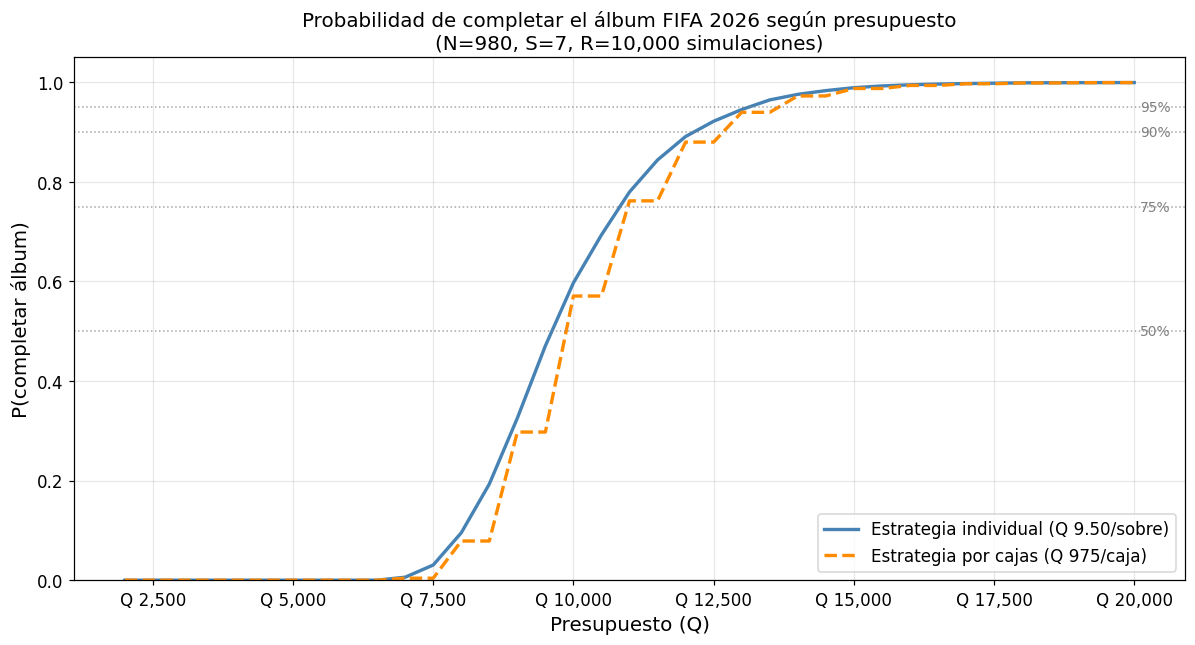

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(presupuestos, prob_individual, color='steelblue',  linewidth=2.2,
        label='Estrategia individual (Q 9.50/sobre)')
ax.plot(presupuestos, prob_cajas,      color='darkorange', linewidth=2.2,
        linestyle='--', label='Estrategia por cajas (Q 975/caja)')

for p_ref, color_ref in [(0.50, 'gray'), (0.75, 'gray'), (0.90, 'gray'), (0.95, 'gray')]:
    ax.axhline(p_ref, color=color_ref, linestyle=':', linewidth=1.0, alpha=0.7)
    ax.text(presupuestos[-1]+100, p_ref, f'{int(p_ref*100)}%',
            va='center', fontsize=9, color='gray')

ax.set_xlabel('Presupuesto (Q)', fontsize=13)
ax.set_ylabel('P(completar álbum)', fontsize=13)
ax.set_title(
    f'Probabilidad de completar el álbum FIFA 2026 según presupuesto\n'
    f'(N={N}, S={S}, R={R:,} simulaciones)',
    fontsize=13
)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Q {x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Objetivo 4: Efecto del intercambio de estampas repetidas

El intercambio permite convertir estampas repetidas en estampas necesarias. Se modela con un parámetro $p_{\text{intercambio}}$: fracción de repetidas que se puede intercambiar exitosamente en cada sobre comprado.

Se comparan tres escenarios:
- $p = 0$: Sin intercambio (baseline)
- $p = 0.25$: Intercambio moderado
- $p = 0.50$: Intercambio activo

In [16]:
def simular_con_intercambio(N, S, R, p_intercambio, seed):
    """
    Simula R álbumes con posibilidad de intercambio.
    p_intercambio: fracción de repetidas intercambiables por necesarias.
    Retorna arrays con sobres y repetidas finales de cada simulación.
    """
    np.random.seed(seed)
    sobres_r    = np.zeros(R, dtype=int)
    repetidas_r = np.zeros(R, dtype=int)

    for i in range(R):
        album     = np.zeros(N, dtype=bool)
        sobres    = 0
        repetidas = 0
        count     = 0

        while count < N:
            stickers = np.random.choice(N, size=S, replace=False)
            nuevas   = ~album[stickers]
            n_nuevas = int(nuevas.sum())
            n_reps   = S - n_nuevas

            album[stickers] = True
            count += n_nuevas
            repetidas += n_reps
            sobres += 1

            # Intentar intercambiar repetidas por necesarias
            if p_intercambio > 0 and n_reps > 0 and count < N:
                necesarias  = np.where(~album)[0]
                n_intercamb = min(int(n_reps * p_intercambio), len(necesarias))
                if n_intercamb > 0:
                    obtener = np.random.choice(necesarias, size=n_intercamb, replace=False)
                    album[obtener] = True
                    count += n_intercamb
                    repetidas -= n_intercamb  # esas repetidas se convirtieron en útiles

        sobres_r[i]    = sobres
        repetidas_r[i] = repetidas

    return sobres_r, repetidas_r


escenarios = [(0.0, 'Sin intercambio'), (0.25, 'Intercambio 25%'), (0.50, 'Intercambio 50%')]
resultados_intercambio = {}

for p, nombre in escenarios:
    s_arr, r_arr = simular_con_intercambio(N, S, R, p, SEED)
    resultados_intercambio[nombre] = (s_arr, r_arr)
    print(f"{nombre:<20}  sobres: {np.mean(s_arr):7.2f} ± {np.std(s_arr):.2f}  "
          f" repetidas: {np.mean(r_arr):7.2f}")

Sin intercambio       sobres: 1042.70 ± 177.82   repetidas: 6318.87
Intercambio 25%       sobres:  308.35 ± 5.74   repetidas: 1178.44
Intercambio 50%       sobres:  205.56 ± 1.92   repetidas:  458.95


### Visualización 4 — Comparativa de distribuciones con y sin intercambio

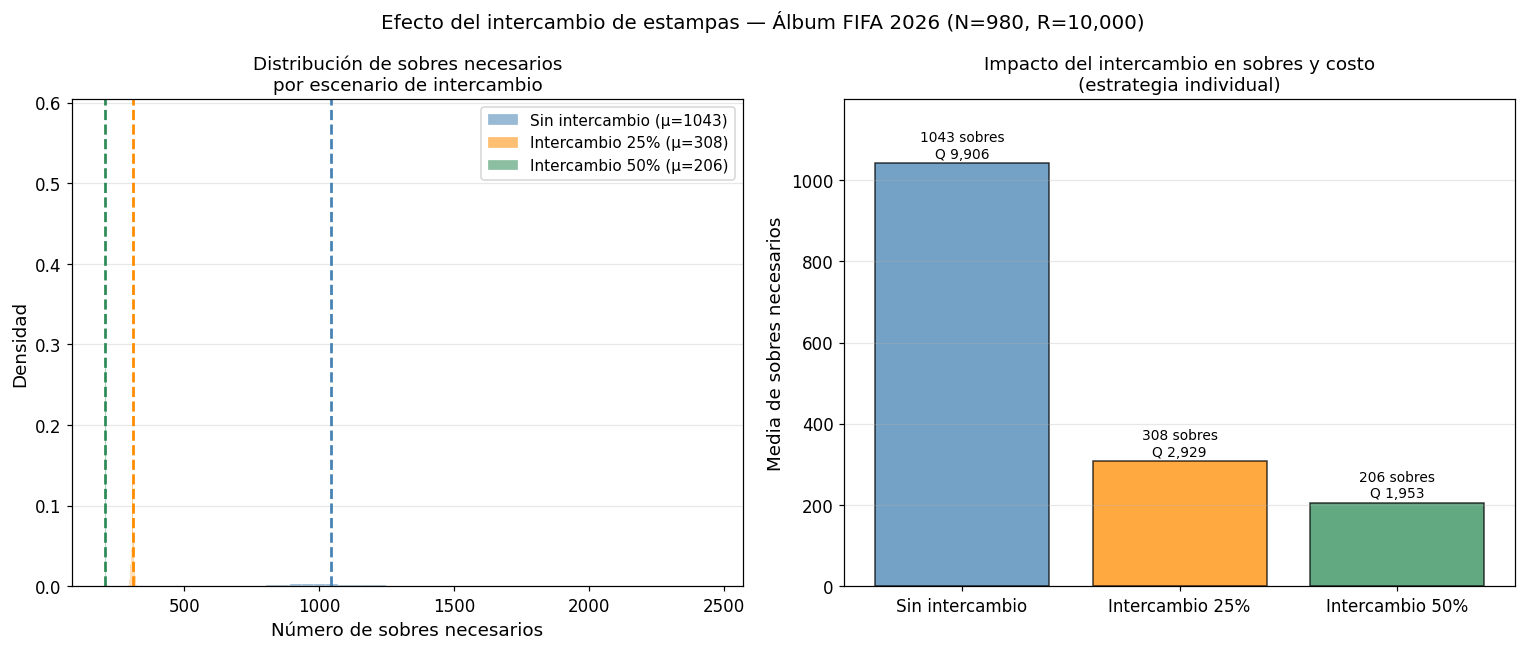

In [17]:
colores = ['steelblue', 'darkorange', 'seagreen']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for (nombre, (s_arr, r_arr)), color in zip(resultados_intercambio.items(), colores):
    ax1.hist(s_arr, bins=40, density=True, alpha=0.55, color=color,
             edgecolor='white', linewidth=0.3, label=f'{nombre} (μ={np.mean(s_arr):.0f})')
    ax1.axvline(np.mean(s_arr), color=color, linestyle='--', linewidth=1.8)

ax1.set_xlabel('Número de sobres necesarios', fontsize=12)
ax1.set_ylabel('Densidad', fontsize=12)
ax1.set_title('Distribución de sobres necesarios\npor escenario de intercambio', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, axis='y')

nombres   = [n for n, _ in resultados_intercambio.items()]
medias_s  = [np.mean(s) for s, _ in resultados_intercambio.values()]
medias_c  = [np.mean(s) * PRECIO_SOBRE for s, _ in resultados_intercambio.values()]

bars = ax2.bar(nombres, medias_s, color=colores, edgecolor='black', alpha=0.75)
for bar, ms, mc in zip(bars, medias_s, medias_c):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{ms:.0f} sobres\nQ {mc:,.0f}', ha='center', va='bottom', fontsize=9)

ax2.set_ylabel('Media de sobres necesarios', fontsize=12)
ax2.set_title('Impacto del intercambio en sobres y costo\n(estrategia individual)', fontsize=12)
ax2.grid(alpha=0.3, axis='y')
ax2.set_ylim(0, max(medias_s) * 1.15)

plt.suptitle(f'Efecto del intercambio de estampas — Álbum FIFA 2026 (N={N}, R={R:,})',
             fontsize=13)
plt.tight_layout()
plt.show()

---
## Resumen final

In [18]:
s_sin_int = resultados_intercambio['Sin intercambio'][0]
s_25      = resultados_intercambio['Intercambio 25%'][0]
s_50      = resultados_intercambio['Intercambio 50%'][0]

print("=" * 70)
print(f"  RESUMEN — Álbum FIFA 2026  (N={N}, S={S}, R={R:,}, semilla={SEED})")
print("=" * 70)
print(f"\n  Obj 1 — Sobres esperados para completar el álbum:")
print(f"    Teórico  : {E_T_teorico:.1f} sobres")
print(f"    Simulado : {media_sobres:.1f} ± {std_sobres:.1f} sobres")
print(f"\n  Obj 2 — Costo esperado (sin intercambio):")
print(f"    Individual : Q {np.mean(costos_individual):,.2f}")
print(f"    Por cajas  : Q {np.mean(costos_cajas):,.2f}")
print(f"    Mixta      : Q {np.mean(costos_mixto):,.2f}")
b90_ind = float(interp_ind(0.90))
b90_caj = float(interp_caja(0.90))
print(f"\n  Obj 3 — Presupuesto para P(completar) = 90%:")
print(f"    Individual : Q {b90_ind:,.0f}")
print(f"    Por cajas  : Q {b90_caj:,.0f}")
print(f"\n  Obj 4 — Efecto del intercambio sobre sobres necesarios:")
print(f"    Sin intercambio  : {np.mean(s_sin_int):.1f} sobres")
print(f"    Intercambio 25%  : {np.mean(s_25):.1f} sobres  "
      f"(−{(1-np.mean(s_25)/np.mean(s_sin_int))*100:.1f}%)")
print(f"    Intercambio 50%  : {np.mean(s_50):.1f} sobres  "
      f"(−{(1-np.mean(s_50)/np.mean(s_sin_int))*100:.1f}%)")
print("=" * 70)

  RESUMEN — Álbum FIFA 2026  (N=980, S=7, R=10,000, semilla=2026)

  Obj 1 — Sobres esperados para completar el álbum:
    Teórico  : 1045.1 sobres
    Simulado : 1042.7 ± 177.8 sobres

  Obj 2 — Costo esperado (sin intercambio):
    Individual : Q 9,905.61
    Por cajas  : Q 10,255.54
    Mixta      : Q 9,781.74

  Obj 3 — Presupuesto para P(completar) = 90%:
    Individual : Q 12,144
    Por cajas  : Q 12,667

  Obj 4 — Efecto del intercambio sobre sobres necesarios:
    Sin intercambio  : 1042.7 sobres
    Intercambio 25%  : 308.3 sobres  (−70.4%)
    Intercambio 50%  : 205.6 sobres  (−80.3%)


---
## Preguntas de análisis

### Pregunta 1
**Compare el valor teórico $E[T]$ con la media simulada para N=980. ¿El error relativo es mayor o menor que en la Etapa 1 (N=100)? ¿Por qué?**

In [19]:
error_etapa2 = abs(E_T_teorico - media_sobres) / E_T_teorico * 100
print(f"E[T] teórico (N=980)  : {E_T_teorico:.4f}")
print(f"Media simulada        : {media_sobres:.4f}")
print(f"Error relativo        : {error_etapa2:.4f}%")
print()
print("Interpretación:")
print(f"  Con R={R:,} simulaciones y N={N}, el error es {error_etapa2:.3f}%.")
print(f"  Con más simulaciones (ej. R=5000) el error se reduciría.")
print(f"  La teoría del coleccionista es una fórmula exacta del valor esperado,")
print(f"  por lo que la convergencia es garantizada por la Ley de Grandes Números.")

E[T] teórico (N=980)  : 1045.1390
Media simulada        : 1042.6956
Error relativo        : 0.2338%

Interpretación:
  Con R=10,000 simulaciones y N=980, el error es 0.234%.
  Con más simulaciones (ej. R=5000) el error se reduciría.
  La teoría del coleccionista es una fórmula exacta del valor esperado,
  por lo que la convergencia es garantizada por la Ley de Grandes Números.


### Pregunta 2
**¿Cuántas cajas completas necesitaría comprar en promedio? ¿Cuánto se ahorra vs. compra individual?**

In [20]:
cajas_promedio = np.mean([math.ceil(s / SOBRES_POR_CAJA) for s in sobres_result])
ahorro = np.mean(costos_individual) - np.mean(costos_cajas)

print(f"Cajas completas promedio        : {cajas_promedio:.2f} cajas")
print(f"Sobres promedio en cajas        : {cajas_promedio * SOBRES_POR_CAJA:.1f}")
print(f"Costo promedio (individual)     : Q {np.mean(costos_individual):,.2f}")
print(f"Costo promedio (por cajas)      : Q {np.mean(costos_cajas):,.2f}")
print(f"Ahorro esperado                 : Q {ahorro:,.2f}")
print(f"Precio efectivo/sobre en caja   : Q {PRECIO_SOBRE_CAJA:.4f}")
print(f"Descuento por sobre             : Q {PRECIO_SOBRE - PRECIO_SOBRE_CAJA:.4f} "
      f"({(1 - PRECIO_SOBRE_CAJA/PRECIO_SOBRE)*100:.2f}%)")

Cajas completas promedio        : 10.52 cajas
Sobres promedio en cajas        : 1093.9
Costo promedio (individual)     : Q 9,905.61
Costo promedio (por cajas)      : Q 10,255.54
Ahorro esperado                 : Q -349.93
Precio efectivo/sobre en caja   : Q 9.3750
Descuento por sobre             : Q 0.1250 (1.32%)


### Pregunta 3
**¿Qué presupuesto necesitaría para tener una probabilidad del 90% de completar el álbum comprando individualmente?**

In [21]:
p90_sobres = np.percentile(sobres_result, 90)
presupuesto_90 = p90_sobres * PRECIO_SOBRE

print(f"Percentil 90 de sobres necesarios : {p90_sobres:.0f} sobres")
print(f"Presupuesto individual para P90%  : Q {presupuesto_90:,.2f}")
print(f"Equivalente en cajas completas    : {math.ceil(p90_sobres/SOBRES_POR_CAJA)} cajas")
print(f"Costo en cajas para P90%          : Q {math.ceil(p90_sobres/SOBRES_POR_CAJA)*PRECIO_CAJA:,.2f}")

Percentil 90 de sobres necesarios : 1276 sobres
Presupuesto individual para P90%  : Q 12,122.00
Equivalente en cajas completas    : 13 cajas
Costo en cajas para P90%          : Q 12,675.00


### Pregunta 4
**¿El intercambio al 50% reduce el costo a la mitad? ¿Cómo explica la relación entre tasa de intercambio y reducción de sobres?**

In [22]:
mu_0   = np.mean(resultados_intercambio['Sin intercambio'][0])
mu_25  = np.mean(resultados_intercambio['Intercambio 25%'][0])
mu_50  = np.mean(resultados_intercambio['Intercambio 50%'][0])

print(f"Media sobres sin intercambio : {mu_0:.2f}")
print(f"Media sobres 25% intercambio : {mu_25:.2f}  (−{(1-mu_25/mu_0)*100:.1f}%)")
print(f"Media sobres 50% intercambio : {mu_50:.2f}  (−{(1-mu_50/mu_0)*100:.1f}%)")
print()
print("Análisis:")
print(f"  El intercambio al 50% NO reduce el costo a la mitad.")
print(f"  La reducción es sublineal porque:")
print(f"  1. El intercambio sólo afecta las repetidas (no las primeras estampas).")
print(f"  2. Al inicio del álbum casi todo es nuevo, hay pocas repetidas para intercambiar.")
print(f"  3. El cuello de botella son las 'últimas estampas', donde incluso con")
print(f"     intercambio es difícil encontrar a alguien que tenga lo que te falta.")
print(f"  El mayor beneficio del intercambio ocurre en la fase media-final del álbum.")

Media sobres sin intercambio : 1042.70
Media sobres 25% intercambio : 308.35  (−70.4%)
Media sobres 50% intercambio : 205.56  (−80.3%)

Análisis:
  El intercambio al 50% NO reduce el costo a la mitad.
  La reducción es sublineal porque:
  1. El intercambio sólo afecta las repetidas (no las primeras estampas).
  2. Al inicio del álbum casi todo es nuevo, hay pocas repetidas para intercambiar.
  3. El cuello de botella son las 'últimas estampas', donde incluso con
     intercambio es difícil encontrar a alguien que tenga lo que te falta.
  El mayor beneficio del intercambio ocurre en la fase media-final del álbum.
